In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import pandas as pd
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from copy import copy
from skimage.filters import gaussian
from scipy.spatial.distance import cdist
import xarray as xr

import sys

sys.path.append("../..")
from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()


INFO:Constants:Logging to file: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Code/Python/pyBayerSMLM/logs/Constants_20251107_175232.log


In [2]:
data_folder = "../Camera_Calibrations/Ximea_Camera/"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B, G, R])

In [3]:
qds = np.sort([x for x in S_F.dye_names if 'Qdot' in x])

In [4]:
qds

array(['Qdot 525', 'Qdot 545', 'Qdot 565', 'Qdot 585', 'Qdot 605',
       'Qdot 625', 'Qdot 655', 'Qdot 705', 'Qdot 800'],
      dtype='<U8')

In [5]:
notch_filter = "semrock-nf03-405-488-561-635e"
dichroic_mirror = "semrock-di03-r405-488-561-635-t1-25x36"
dichroic_515_mirror = "semrock-di03-r514-t1-25x36"
nilered_filter = "semrock-ff01-650-200"
shortpass_filter = "semrock-bsp01-785r"
longpass_filter_515 = "semrock-ff01-515-lp"

filters = [dichroic_515_mirror]

In [6]:
wavelengths, pixels = S_F.get_pixel_fractions_dye_and_filters(dyes=qds, filters=filters, pixel_QYs=pixel_QYs, wavelength=wavelength)

In [7]:
pixels

array([[ 0.12321813,  0.82091863,  0.05586324],
       [ 0.09427189,  0.84652086,  0.05920724],
       [ 0.05149745,  0.78472668,  0.16377587],
       [ 0.02359155,  0.48509676,  0.49131169],
       [ 0.01867248,  0.32959695,  0.65173057],
       [ 0.02348863,  0.22856825,  0.74794312],
       [ 0.0508016 ,  0.17107789,  0.77812051],
       [ 0.06853557,  0.27566043,  0.655804  ],
       [ 0.17421112,  0.3270448 ,  0.49874408]])

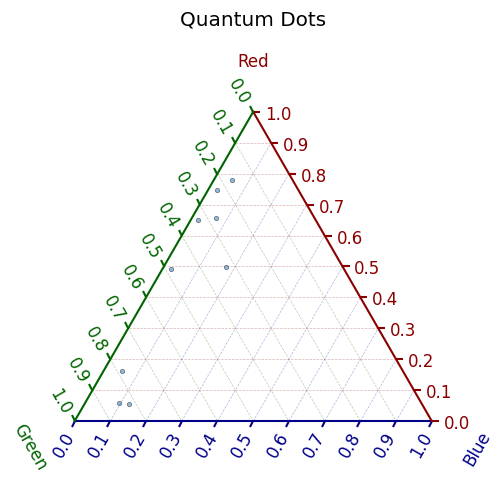

In [8]:
from PlottingBase import PublicationPlotter

plotter = PublicationPlotter()

# Scatter plot
fig, ax = plotter.create_ternary_plot(R=pixels[:, -1], G=pixels[:, -2], B=pixels[:, -3], title='Quantum Dots')

# Density plot
#fig, ax = plotter.create_ternary_density(R, G, B, gridsize=100, cmap='viridis')

#fig.savefig('ternary.png', dpi=300, bbox_inches='tight')